In [1]:
%matplotlib inline

import s3fs
import re
import rioxarray
import xarray as xr

from datacube.utils import geometry
from datacube.utils.cog import write_cog


In [2]:
# Initialize the S3 filesystem (using anonymous access)
fs = s3fs.S3FileSystem(anon=True)

def get_files_from_product(product_item):
    """
    Given a product item, return a list of filtered files from the S3 folder.
    It fetches all files under the folder and filters based on the specified extension.
    """
    # Define the S3 folder path
    s3_folder = product_item["product_folder"]

    # Efficiently list all files in the folder and subfolders
    all_files = fs.glob(s3_folder + '/**')
    
    # Filter files that match the required extension
    filtered_files = [file for file in all_files if file.endswith(product_item["extension_name"])]
    
    return filtered_files


def extract_info(file_path):
    """
    Extracts x and y tile information from a file path using regex.
    This info is formatted as 'x14/y32', useful for organizing file storage.
    """
    pattern = r'/x(\d+)/y(\d+)/'
    match = re.search(pattern, file_path)
    if match:
        x_tile = match.group(1)
        y_tile = match.group(2)
        return f'x{x_tile}/y{y_tile}'
    return None

In [3]:
def process_files(base_product_file, match_products):
    """
    Process a base product file, search for corresponding files from the match_products,
    and perform weighted burn_mapping, returning the combined result.
    """
    # Extract pattern (e.g., x and y coordinates) from the base file
    pattern = extract_info(base_product_file)
    
    # Skip processing if pattern extraction fails
    if not pattern:
        return None
    
    pair_files = []
    
    # Collect matching files from each product
    for match_product in match_products:
        # Build the target folder path dynamically
        target_folder = f"{match_product['product_folder']}/{pattern}/"
        
        # List files in the specific target folder
        all_files = fs.glob(target_folder + '**')
        
        # Filter matching files by extension and store with product weight
        matching_files = [file for file in all_files if file.endswith(match_product["extension_name"])]
        
        if matching_files:
            pair_files.append({"file_path": matching_files[0], "product_weight": match_product["product_weight"]})
    
    # If no files matched, skip further processing
    if not pair_files:
        return None
    
    # Open and process all matching files
    da_list = []
    for pair_file in pair_files:
        # Open raster data from S3
        da = rioxarray.open_rasterio(f"s3://{pair_file['file_path']}")
        # Apply product weight
        da_list.append(da * pair_file["product_weight"])
    
    # Concatenate along a new "variable" dimension and sum across it
    combined = xr.concat(da_list, dim="variable")
    sum_summary = combined.sum(dim="variable")
    
    # Add CRS (Coordinate Reference System) to the output
    sum_summary.attrs["crs"] = geometry.CRS("EPSG:3577")
    
    return sum_summary, pattern

In [8]:
# Main loop to process each base product file
match_products = [
    {"product_folder": "s3://dea-public-data-dev/projects/burn_cube/derivative/dea_ml_ba_rf_with_landcover_xgb_model_02_08_2024/3-0-0", 
     "extension_name": "prediction_object.tif", "product_weight": 1},
    {"product_folder": "s3://dea-public-data-dev/projects/burn_cube/derivative/ga_ls8c_nbart_bc_7bands_4years_cyear_3/3-0-0", 
     "extension_name": "wofssevere.tif", "product_weight": 1},
    {"product_folder": "s3://dea-public-data-dev/projects/burn_cube/derivative/dea_ml_ba_rf_with_landcover_rf_model_08_02_2024/3-0-0", 
     "extension_name": "prediction_object.tif", "product_weight": 1}
]

# Use the first product as the base product
base_product_files = get_files_from_product(match_products[0])

# Limit processing to the first 4 files for efficiency (or batch processing)
for base_product_file in base_product_files[:10]:
    result = process_files(base_product_file, match_products)
    
    if result:
        sum_summary, pattern = result
        # Write the result to a COG file
        write_cog(
            geo_im=sum_summary,
            fname="dea_burn_mapping_" + pattern.replace("/", "") + "_2020.tif",
            overwrite=True
        )

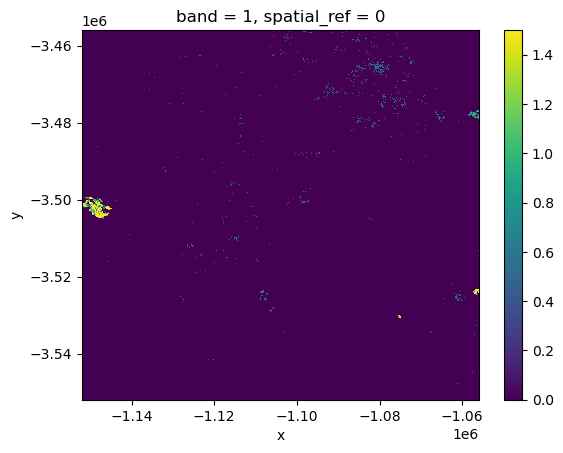

In [6]:
sum_summary.plot()